# Modeling HUPA0003's using an RNN, glucose are considered as the only input at each step t  

In addition, in this notebook we take an approach of the form sequence to vector i.e. given a sequence we predict just a single step instead of several steps 

In [432]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Get data 

In [433]:
glucose = pd.read_csv('../Data/Preprocessed/HUPA0027P.csv', sep=';')['glucose']

In [434]:
glucose

0         112.0
1         105.0
2          98.0
3          91.0
4          91.0
          ...  
165301     78.0
165302     72.0
165303     66.0
165304     63.0
165305     60.0
Name: glucose, Length: 165306, dtype: float64

Normalize glucose 


In [435]:
from sklearn.preprocessing import MinMaxScaler

In [436]:
scaler = MinMaxScaler(feature_range=(0,1))
normalized_glucose = scaler.fit_transform(glucose.values.reshape(-1,1)).flatten()

## Architecture 

- input_size = 1 (Size of vector at each time step)
- hidden_size = 4 (Number of recurrent neurons)
- batch_size = 12

In [437]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Prepare data 

Import our own class 

In [438]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [439]:
batch_size = 16
input_size = 1
hidden_size = 8
window_size = 6
steps_ahead = 3
test_size = 0.2

In [440]:
data = Window_Regressor_Sequence_to_scalar(time_series_data=pd.Series(normalized_glucose), window_size=window_size, horizon=steps_ahead).generate_data_set()
split_location = int(len(data) * 0.8)
train, test = data[:split_location], data[split_location:]

Prepare our data to feed to our model 

In [441]:
train_tensor = torch.tensor(data=train.values, dtype=torch.float32)
test_tensor = torch.tensor(data=test.values, dtype=torch.float32)

In [442]:
train_torch_data_set = TensorDataset(train_tensor)
train_loader = DataLoader(dataset=train_torch_data_set, batch_size=batch_size)

Define the model

In [443]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn_1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.linear_layer = nn.Linear(in_features=hidden_size, out_features=1)
        
    
    def forward(self, x):
        output_recurrent_layer, _ = self.rnn_1(x) ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
        prediction = self.linear_layer(output_recurrent_layer[:, -1, :])  ## We want to keep just the last output for the last element of each sequence 
        return prediction.squeeze(-1) ## To obtain (Batch,) instead of (Batch, 1)
        

In [444]:
model = LSTM(input_size=input_size, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()
epochs = 100

Train the model 

In [445]:
for e in range(epochs):
    loss_batch_array = []
    for x in train_loader:
        batch = x[0]
        x = batch[:, :-1].unsqueeze(-1) ## To obtain (Batch, window, input) instead of (Batch, window)
        y = batch[:, -1]
        y_pred = model(x)

        optimizer.zero_grad()
        loss = loss_function(y_pred, y)
        loss.backward()
        optimizer.step()

    
        loss_batch_array.append(loss.item())

    if e % 10 == 0:
        print(f'Epoch {e} average loss:{np.array(loss_batch_array).mean()}')


Epoch 0 average loss:0.0018328944535421568
Epoch 10 average loss:0.0004219186006274091
Epoch 20 average loss:0.00041335505233994023
Epoch 30 average loss:0.00041058695421849464
Epoch 40 average loss:0.0004086102128658919
Epoch 50 average loss:0.00040620205550295145
Epoch 60 average loss:0.00040348410616157304
Epoch 70 average loss:0.00040153852619700427
Epoch 80 average loss:0.00039961311163103677
Epoch 90 average loss:0.0003974406023670206


Test the model

In [446]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [447]:
test

,Predictor_0,Predictor_1,Predictor_2,Predictor_3,Predictor_4,Predictor_5,Target
132238,0.218487,0.218487,0.218487,0.220355,0.222222,0.224090,0.229692
132239,0.218487,0.218487,0.220355,0.222222,0.224090,0.225957,0.227824
132240,0.218487,0.220355,0.222222,0.224090,0.225957,0.227824,0.225957
132241,0.220355,0.222222,0.224090,0.225957,0.227824,0.229692,0.224090
132242,0.222222,0.224090,0.225957,0.227824,0.229692,0.227824,0.218487
...,...,...,...,...,...,...,...
165293,0.072829,0.072829,0.084034,0.095238,0.106443,0.112045,0.106443
165294,0.072829,0.084034,0.095238,0.106443,0.112045,0.117647,0.089636
165295,0.084034,0.095238,0.106443,0.112045,0.117647,0.123249,0.072829
165296,0.095238,0.106443,0.112045,0.117647,0.123249,0.106443,0.064426


MAPE:0.036038704216480255
MAE:4.1293134689331055
MSE:42.88117980957031


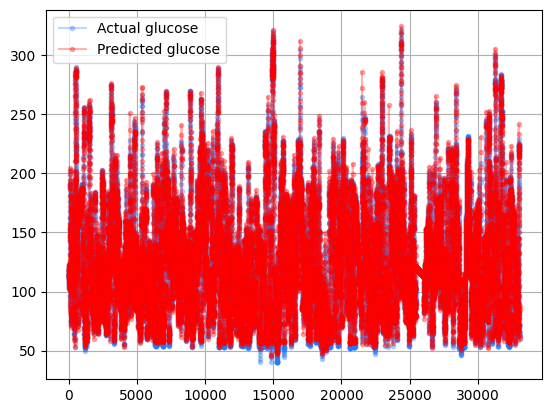

In [448]:
with torch.no_grad():
        x = test_tensor[:, :-1]
        y = scaler.inverse_transform(test_tensor[:, -1].numpy().reshape(-1,1))
        y_pred = scaler.inverse_transform(model(x.unsqueeze(-1)).numpy().reshape(-1,1))
        mape = mean_absolute_percentage_error(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        print(f'MAPE:{mape}')
        print(f'MAE:{mae}')
        print(f'MSE:{mse}')
        plt.plot(range(len(y)), y, label='Actual glucose', marker='.', color='#237AFC', alpha=0.3)
        plt.plot(range(len(y)), y_pred, label='Predicted glucose', marker='.', color='red', alpha=0.3)
        plt.legend()
        plt.grid()
        plt.show()